#### Import Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Import Datasets

In [40]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test

#### Random Forest Regression

In [41]:
random_forest_reg = RandomForestRegressor(n_estimators=70, max_features=7, max_depth=5, n_jobs=-1, random_state=1)

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

random_forest_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)

rf_reg_pred_train = random_forest_reg.predict(Set1_X_Train_scaled)
rf_reg_pred_test = random_forest_reg.predict(Set1_X_Test_scaled)

rf_reg_pred_train_int = rf_reg_pred_train.astype(int)
rf_reg_pred_test_int = rf_reg_pred_test.astype(int)

#### Random Forest Evaluation

In [42]:
# Mean Squared Error
mse_train_rf = mean_squared_error(Set1_y_Train_array, rf_reg_pred_train_int)
mse_test_rf = mean_squared_error(Set1_y_Test_array, rf_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)

# Mean Absolute Error
mae_train_rf = mean_absolute_error(Set1_y_Train_array, rf_reg_pred_train_int)
mae_test_rf = mean_absolute_error(Set1_y_Test_array, rf_reg_pred_test_int)

# R2 Score
r2_train_rf = r2_score(Set1_y_Train_array, rf_reg_pred_train_int)
r2_test_rf = r2_score(Set1_y_Test_array, rf_reg_pred_test_int)

# Coefficient of Determination
cod_train_rf = explained_variance_score(Set1_y_Train_array, rf_reg_pred_train_int)
cod_test_rf = explained_variance_score(Set1_y_Test_array, rf_reg_pred_test_int)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf)
print("Root Mean Squared Error:", rmse_train_rf)
print("Mean Absolute Error:", mae_train_rf)
print("R-squared Score:", r2_train_rf)
print("Coefficient of Determination:", cod_train_rf)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf)
print("Root Mean Squared Error:", rmse_test_rf)
print("Mean Absolute Error:", mae_test_rf)
print("R-squared Score:", r2_test_rf)
print("Coefficient of Determination:", cod_test_rf)

--Training Set Evaluation--
Mean Squared Error: 1786.4986185836847
Root Mean Squared Error: 42.26699206926943
Mean Absolute Error: 30.331103678929765
R-squared Score: 0.6234479878074151
Coefficient of Determination: 0.6234865543900512

--Testing Set Evaluation--
Mean Squared Error: 850.56
Root Mean Squared Error: 29.164361813693095
Mean Absolute Error: 21.7
R-squared Score: 0.5074555716308862
Coefficient of Determination: 0.510009325544905


#### Plot Evaluation Results

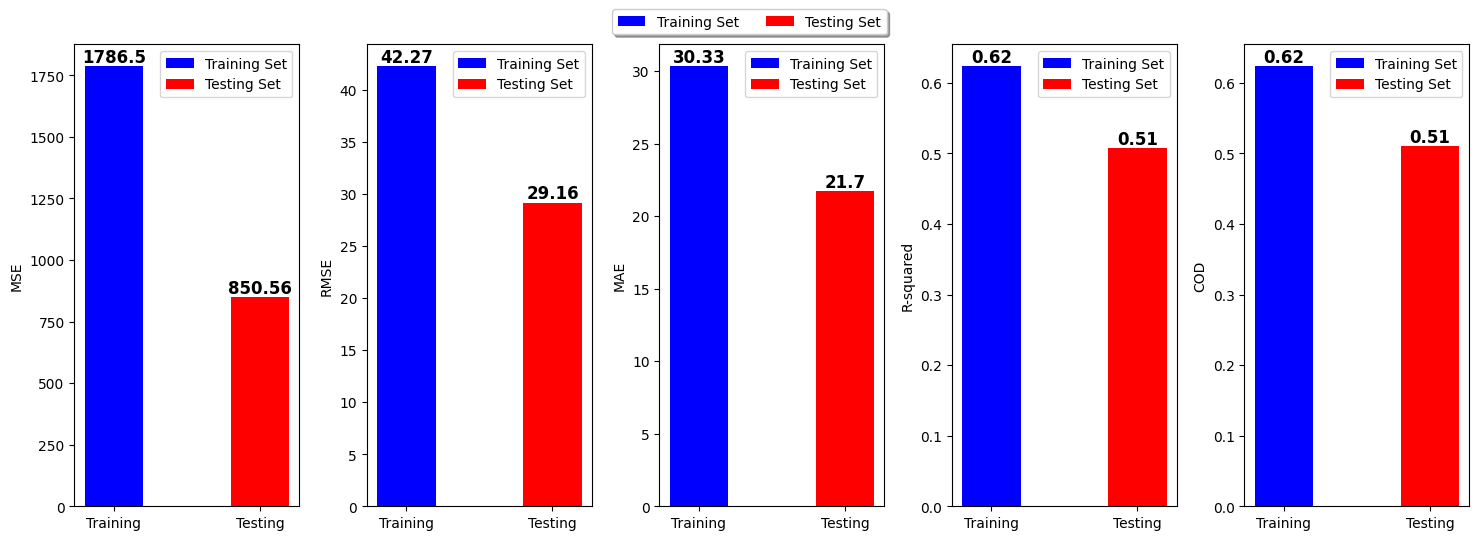

In [43]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_rf, rmse_train_rf, mae_train_rf, r2_train_rf, cod_train_rf]
test_metrics = [mse_test_rf, rmse_test_rf, mae_test_rf, r2_test_rf, cod_test_rf]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Predicted vs Actual Values

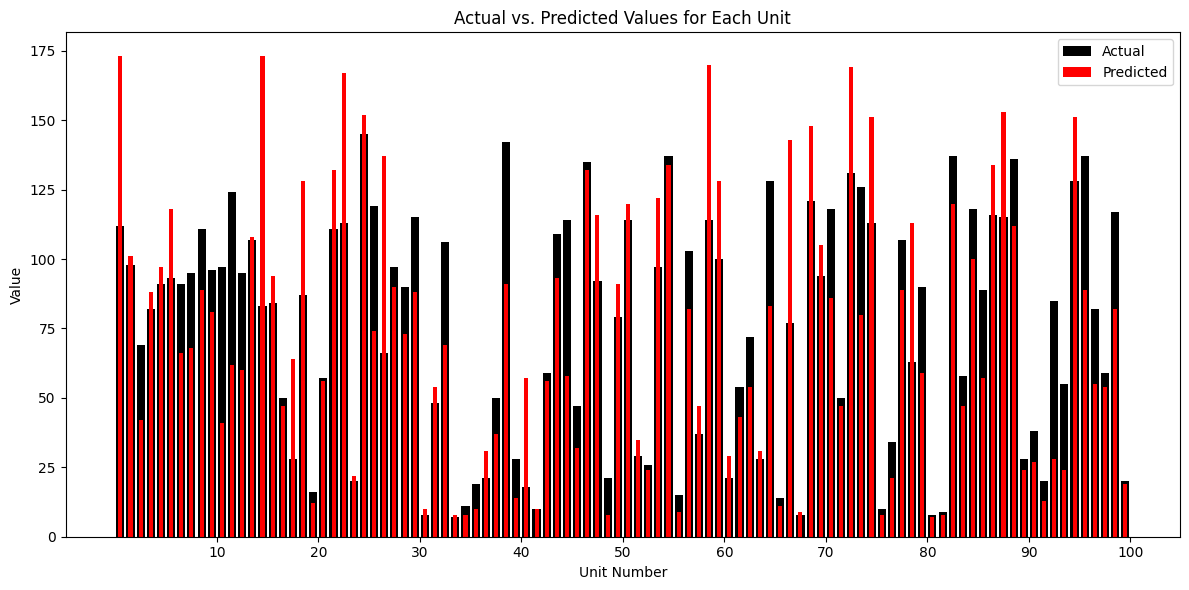

In [44]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(rf_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()